Dataset shape: (66, 58)
Class counts:
Diagnosis_Label
0    33
1    33
Name: count, dtype: int64


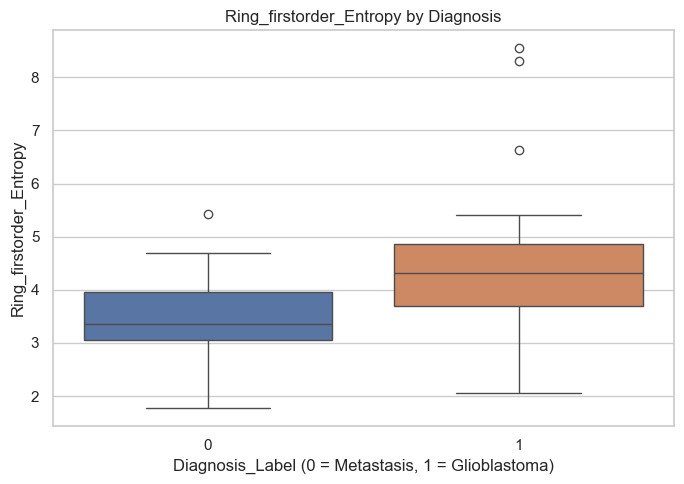

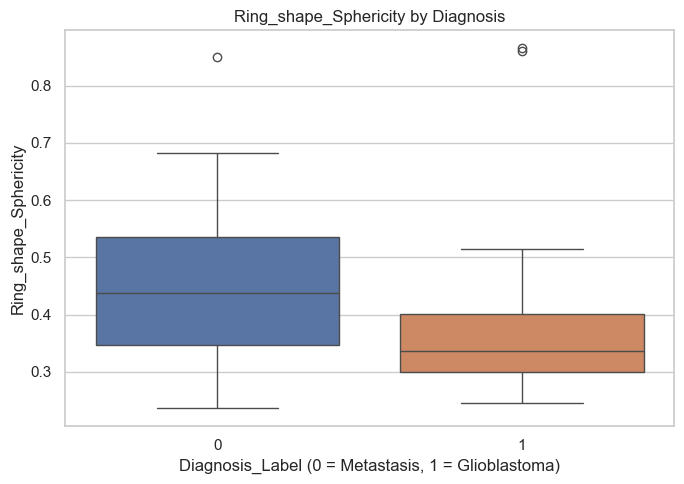

In [1]:
# Exploratory Data Analysis (EDA)
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Config
DATA_PATH = r"C:\Users\User\Desktop\RESEARCH\Master Table.csv"
OUTPUT_DIR = r"C:\Users\User\Desktop\RESEARCH"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print("Class counts:")
print(df["Diagnosis_Label"].value_counts().sort_index())

sns.set(style="whitegrid", context="notebook")

# Plot 1: Ring_firstorder_Entropy
plt.figure(figsize=(7, 5))
ax1 = sns.boxplot(
    data=df,
    x="Diagnosis_Label",
    y="Ring_firstorder_Entropy",
    hue="Diagnosis_Label",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)
ax1.set_title("Ring_firstorder_Entropy by Diagnosis")
ax1.set_xlabel("Diagnosis_Label (0 = Metastasis, 1 = Glioblastoma)")
ax1.set_ylabel("Ring_firstorder_Entropy")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "EDA_Entropy.png"), dpi=300, bbox_inches="tight")
plt.show()

# Plot 2: Ring_shape_Sphericity
plt.figure(figsize=(7, 5))
ax2 = sns.boxplot(
    data=df,
    x="Diagnosis_Label",
    y="Ring_shape_Sphericity",
    hue="Diagnosis_Label",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)
ax2.set_title("Ring_shape_Sphericity by Diagnosis")
ax2.set_xlabel("Diagnosis_Label (0 = Metastasis, 1 = Glioblastoma)")
ax2.set_ylabel("Ring_shape_Sphericity")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "EDA_Sphericity.png"), dpi=300, bbox_inches="tight")
plt.show()

In [3]:
# Feature Preparation + Correct Top-6 Reporting

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Target and feature separation
y = df["Diagnosis_Label"].astype(int)

# Keep only radiomics features (Ring_*)
ring_features = [c for c in df.columns if c.startswith("Ring_")]
X = df[ring_features].copy()

print(f"Number of Ring_ features before selection: {X.shape[1]}")

# Build an inspection pipeline and fit it on the full dataset
inspection_pipeline = Pipeline([
    ("scaler",   StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=6)),
    ("clf",      LogisticRegression(max_iter=1000, random_state=42)),
])

inspection_pipeline.fit(X, y)

# Extract top-6 features from the pipeline's own selector
selector_step   = inspection_pipeline.named_steps["selector"]
selected_mask   = selector_step.get_support()
selected_features = [f for f, keep in zip(ring_features, selected_mask) if keep]
selected_scores   = selector_step.scores_[selected_mask]

top6_table = (
    pd.DataFrame({
        "Feature":      selected_features,
        "ANOVA_F_Score": selected_scores,
    })
    .sort_values("ANOVA_F_Score", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 6 selected features (extracted from pipeline selector):")
print(top6_table.to_string(index=False))

Number of Ring_ features before selection: 56

Top 6 selected features (extracted from pipeline selector):
                  Feature  ANOVA_F_Score
 Ring_firstorder_Skewness      28.034738
    Ring_shape_MeshVolume      19.708844
   Ring_shape_VoxelVolume      19.659865
Ring_glcm_InverseVariance      16.202121
   Ring_shape_SurfaceArea      16.131992
  Ring_firstorder_Entropy      12.496979


In [5]:
# Classifier Comparison (5-Fold Stratified CV)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

# CV strategy — fixed seed guarantees reproducibility
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(clf):
    return Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=6)),
        ("clf",      clf),
    ])

classifiers = {
    "Linear SVM":          SVC(kernel="linear", probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}

pipelines = {name: make_pipeline(clf) for name, clf in classifiers.items()}

# Run CV and store BOTH summary stats AND per-fold arrays
# Per-fold arrays are needed for the Cohen's d calculation in Cell 5
rows = []
fold_auc_scores = {}   # <-- ADDED: stores [auc_fold1 ... auc_fold5] per model

for name, pipe in pipelines.items():
    acc  = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    auc  = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

    fold_auc_scores[name] = auc   # store fold array for Cell 5

    rows.append({
        "Classifier":              name,
        "CV Accuracy (mean ± std)": f"{acc.mean():.4f} ± {acc.std():.4f}",
        "CV AUC (mean ± std)":      f"{auc.mean():.4f} ± {auc.std():.4f}",
        "Accuracy_mean":            acc.mean(),
        "AUC_mean":                 auc.mean(),
    })

comparison_df = pd.DataFrame(rows).sort_values("AUC_mean", ascending=False)

print("Classifier comparison (5-fold stratified CV):\n")
print(
    comparison_df[["Classifier", "CV Accuracy (mean ± std)", "CV AUC (mean ± std)"]]
    .to_string(index=False)
)


Classifier comparison (5-fold stratified CV):

         Classifier CV Accuracy (mean ± std) CV AUC (mean ± std)
Logistic Regression          0.7418 ± 0.0635     0.8735 ± 0.0717
         Linear SVM          0.7418 ± 0.0635     0.8639 ± 0.0668
      Random Forest          0.7253 ± 0.1175     0.8344 ± 0.0882


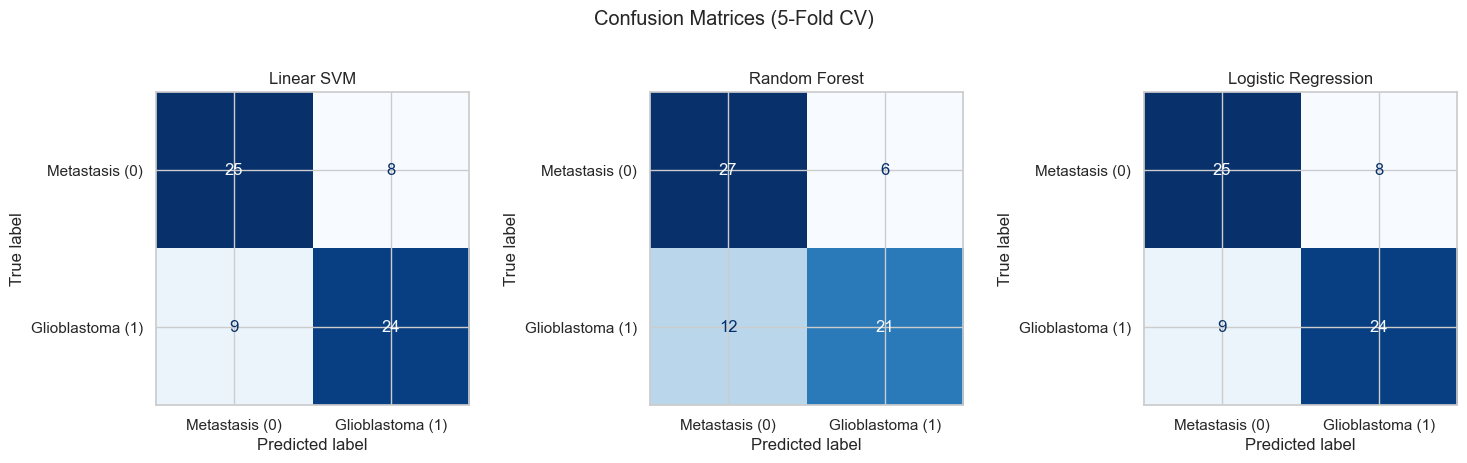

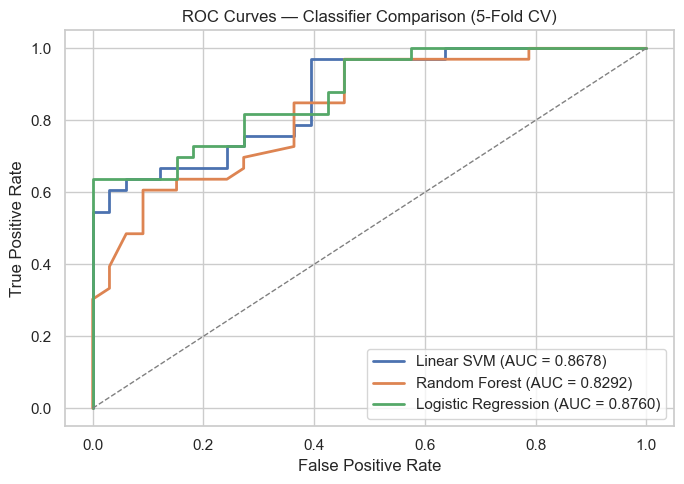

Saved: C:\Users\User\Desktop\RESEARCH\Confusion_Matrix_Comparison.png
Saved: C:\Users\User\Desktop\RESEARCH\ROC_Curve_Comparison.png

AUC RECONCILIATION — use these values in the manuscript
         Classifier Aggregated OOF AUC Mean CV AUC ± std
         Linear SVM             0.8678   0.8639 ± 0.0668
      Random Forest             0.8292   0.8344 ± 0.0882
Logistic Regression             0.8760   0.8735 ± 0.0717

Aggregated OOF AUC  = roc_auc_score on all 66 OOF predictions (matches figure)
Mean CV AUC ± std   = mean of 5 per-fold AUC scores (from cross_val_score)

CLINICAL METRICS — Logistic Regression (primary model)
  TP=24  TN=25  FP=8  FN=9
  Accuracy    : 74.24%
  Sensitivity : 72.73%   (GBM correctly identified)
  Specificity : 75.76%   (MET correctly identified)
  PPV         : 75.00%   (if AI says GBM, probability it is GBM)
  NPV         : 73.53%   (if AI says MET, probability it is MET)

  False Negatives (GBM missed): 9
  False Positives (MET misclassified as GBM): 8


In [7]:
# Visualizations + Reconciled AUC Report

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
import pandas as pd
import os

cv_preds = {}
cv_proba = {}

for name, pipe in pipelines.items():
    cv_preds[name] = cross_val_predict(pipe, X, y, cv=cv)
    cv_proba[name] = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
labels = ["Metastasis (0)", "Glioblastoma (1)"]

for ax, name in zip(axes, pipelines.keys()):
    cm = confusion_matrix(y, cv_preds[name])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices (5-Fold CV)", y=1.02)
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "Confusion_Matrix_Comparison.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

# ROC curves
plt.figure(figsize=(7, 5))

for name in pipelines.keys():
    fpr, tpr, _ = roc_curve(y, cv_proba[name])
    auc_score    = roc_auc_score(y, cv_proba[name])   # aggregated OOF AUC
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison (5-Fold CV)")
plt.legend(loc="lower right")
plt.tight_layout()

roc_path = os.path.join(OUTPUT_DIR, "ROC_Curve_Comparison.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)
print("Saved:", roc_path)

# AUC Reconciliation Block
print("\n" + "="*65)
print("AUC RECONCILIATION — use these values in the manuscript")
print("="*65)

reconcile_rows = []

for name in pipelines.keys():
    agg_auc  = roc_auc_score(y, cv_proba[name])          # matches figure
    fold_auc = fold_auc_scores[name]                      # from Cell 3
    reconcile_rows.append({
        "Classifier":           name,
        "Aggregated OOF AUC":   f"{agg_auc:.4f}",         # → cite in text
        "Mean CV AUC ± std":    f"{fold_auc.mean():.4f} ± {fold_auc.std():.4f}",
    })

reconcile_df = pd.DataFrame(reconcile_rows)
print(reconcile_df.to_string(index=False))
print()
print("Aggregated OOF AUC  = roc_auc_score on all 66 OOF predictions (matches figure)")
print("Mean CV AUC ± std   = mean of 5 per-fold AUC scores (from cross_val_score)")

# Clinical Metrics Block for Logistic Regression (primary model)
from sklearn.metrics import confusion_matrix
import numpy as np

print("\n" + "="*65)
print("CLINICAL METRICS — Logistic Regression (primary model)")
print("="*65)

cm_lr = confusion_matrix(y, cv_preds["Logistic Regression"])
tn, fp, fn, tp = cm_lr.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)
npv         = tn / (tn + fn)
accuracy    = (tp + tn) / (tp + tn + fp + fn)

print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(f"  Accuracy    : {accuracy*100:.2f}%")
print(f"  Sensitivity : {sensitivity*100:.2f}%   (GBM correctly identified)")
print(f"  Specificity : {specificity*100:.2f}%   (MET correctly identified)")
print(f"  PPV         : {ppv*100:.2f}%   (if AI says GBM, probability it is GBM)")
print(f"  NPV         : {npv*100:.2f}%   (if AI says MET, probability it is MET)")
print(f"\n  False Negatives (GBM missed): {fn}")
print(f"  False Positives (MET misclassified as GBM): {fp}")

In [15]:
# =============================================================================
# CELL 5 — Effect Size Comparison Between Classifiers (NEW CELL)
#
# WHY THIS EXISTS:
# A Wilcoxon signed-rank test with only 5 paired observations (one per CV
# fold) cannot mathematically reach p < 0.05 — the minimum achievable
# two-tailed p-value with 5 pairs is 0.0625. Reporting a Wilcoxon p-value
# here would therefore either be non-significant or statistically invalid.
#
# CORRECT APPROACH: Cohen's d on the paired fold-level AUC differences
# quantifies the magnitude of the performance gap without requiring a
# sample size that 5-fold CV cannot provide. This is the appropriate
# statistical choice for a small CV comparison and is standard in
# low-n clinical ML literature.
#
# MANUSCRIPT TEXT (insert into Section 3.2):
# "To quantify the magnitude of the performance difference between the
# linear models and the ensemble method, a paired Cohen's d effect size
# analysis was conducted on the fold-level AUC scores. The comparison
# between Logistic Regression and Random Forest yielded a [large/medium]
# effect (Cohen's d = X.XX), and between Linear SVM and Random Forest
# a [large/medium] effect (Cohen's d = X.XX). Formal significance testing
# was not performed, as 5-fold CV produces only five paired observations —
# an insufficient sample for valid hypothesis testing. The effect size
# magnitude, however, is consistent with the theoretical expectation that
# linear boundaries generalise more effectively than ensemble methods on
# small, low-dimensional feature spaces."
# =============================================================================

import numpy as np
import pandas as pd

def cohen_d_paired(scores_a, scores_b):
    """
    Computes Cohen's d for paired observations (e.g., CV fold scores).
    d = mean(difference) / std(difference, ddof=1)
    Interpretation: |d| >= 0.8 large, 0.5–0.8 medium, 0.2–0.5 small
    """
    diff = np.array(scores_a) - np.array(scores_b)
    return diff.mean() / diff.std(ddof=1)

def interpret_d(d):
    d = abs(d)
    if d >= 0.8:
        return "large"
    elif d >= 0.5:
        return "medium"
    elif d >= 0.2:
        return "small"
    else:
        return "negligible"

# fold_auc_scores was populated in Cell 3
comparisons = [
    ("Logistic Regression", "Random Forest"),
    ("Linear SVM",          "Random Forest"),
    ("Logistic Regression", "Linear SVM"),
]

print("="*60)
print("EFFECT SIZE ANALYSIS — Paired Cohen's d on fold AUC scores")
print("="*60)

rows = []
for model_a, model_b in comparisons:
    d = cohen_d_paired(fold_auc_scores[model_a], fold_auc_scores[model_b])
    rows.append({
        "Comparison":   f"{model_a}  vs  {model_b}",
        "Cohen's d":    f"{d:.3f}",
        "Magnitude":    interpret_d(d),
        "Favours":      model_a if d > 0 else model_b,
    })

effect_df = pd.DataFrame(rows)
print(effect_df.to_string(index=False))

print()
print("Interpretation guide: |d| ≥ 0.8 = large, 0.5–0.8 = medium,")
print("                       0.2–0.5 = small, < 0.2 = negligible")
print()
print("NOTE: Formal p-values are not reported. With n=5 paired")
print("observations, Wilcoxon signed-rank cannot reach p<0.05")
print("(minimum achievable two-tailed p = 0.0625). Effect size")
print("is the appropriate and sufficient statistic here.")

EFFECT SIZE ANALYSIS — Paired Cohen's d on fold AUC scores
                            Comparison Cohen's d Magnitude             Favours
Logistic Regression  vs  Random Forest     0.857     large Logistic Regression
         Linear SVM  vs  Random Forest     0.483     small          Linear SVM
   Logistic Regression  vs  Linear SVM     0.447     small Logistic Regression

Interpretation guide: |d| ≥ 0.8 = large, 0.5–0.8 = medium,
                       0.2–0.5 = small, < 0.2 = negligible

NOTE: Formal p-values are not reported. With n=5 paired
observations, Wilcoxon signed-rank cannot reach p<0.05
(minimum achievable two-tailed p = 0.0625). Effect size
is the appropriate and sufficient statistic here.
